<a href="https://colab.research.google.com/github/DR-cod-sust/Mineria_DataMining_Course/blob/main/7b_economies_regression_24_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión de Economías Mundiales 🌍📈  
## Comparación de **24 modelos de regresión** con Train/Validation/Test (50/25/25) 🤖✅

**Objetivo del notebook (paso a paso):**
1) Generar una base simulada realista de **10,000 filas** con variables económicas 🌍🧾  
2) Definir una variable objetivo **continua** (p.ej. *Economic Performance Score*) 🎯  
3) Split **50% train / 25% validation / 25% test** 📦  
4) Entrenar **24 algoritmos de regresión** evitando *data leakage* con `Pipeline` 🧯  
5) Evaluar con métricas de desempeño (**performance metrics**) 📏  
6) Diagnosticar **overfitting / underfitting** con el **gap train vs validation** 🔍  
7) Comparar modelos con un sistema de **ranking** (1 = mejor, 24 = peor) 🏆  
8) Ordenar de mejor a peor por suma de rankings ✅

> Nota: El dataset se simula con **ruido** para evitar “resultados perfectos” (R²≈1.0) 🚫💯.

## 0) Setup ⚙️

In [12]:
# If needed (Colab):
# !pip -q install scikit-learn pandas numpy matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 24 regression models (scikit-learn)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge,
    HuberRegressor, TheilSenRegressor, SGDRegressor
)
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    AdaBoostRegressor, BaggingRegressor, HistGradientBoostingRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

from sklearn.cross_decomposition import PLSRegression
from sklearn.isotonic import IsotonicRegression

## 1) Generar base simulada (10,000 filas) 🌍🧾

Creamos un dataset con variables numéricas (índices macro) y categorías (región, grupo de ingreso, bloque comercial, régimen cambiario).
La variable objetivo es un **score continuo** con relación no lineal + interacción + ruido.

In [13]:
rng = np.random.default_rng(42)
n = 10_000

# Base numérica con make_regression (incluye ruido)
X_num, y_base = make_regression(
    n_samples=n,
    n_features=12,
    n_informative=8,
    noise=35.0,
    random_state=42
)

num_cols = [
    "gdp_per_capita_index",
    "inflation_index",
    "unemployment_index",
    "gdp_growth_index",
    "debt_to_gdp_index",
    "trade_openness_index",
    "investment_index",
    "education_index",
    "health_index",
    "governance_index",
    "technology_index",
    "energy_security_index"
]

df = pd.DataFrame(X_num, columns=num_cols)

# Variables "más interpretables" (aún simuladas)
df["inflation_rate_%"] = (df["inflation_index"] * 2.2 + 3.0) + rng.normal(0, 1.3, size=n)
df["gdp_growth_%"]     = (df["gdp_growth_index"] * 1.7 + 2.0) + rng.normal(0, 0.9, size=n)
df["debt_to_gdp_%"]    = np.clip((df["debt_to_gdp_index"] * 14 + 65) + rng.normal(0, 12, size=n), 5, 240)

# Categóricas
regions = np.array(["Americas", "Europe", "Asia", "Africa", "Oceania", "MiddleEast"])
income_groups = np.array(["Low", "LowerMiddle", "UpperMiddle", "High"])
trade_blocs = np.array(["NAFTA/USMCA", "EU", "ASEAN", "Other"])
currency_regimes = np.array(["Float", "Peg", "Managed"])

df["region"] = rng.choice(regions, size=n, replace=True, p=[0.22, 0.18, 0.28, 0.20, 0.03, 0.09])
df["income_group"] = rng.choice(income_groups, size=n, replace=True, p=[0.18, 0.27, 0.33, 0.22])
df["trade_bloc"] = rng.choice(trade_blocs, size=n, replace=True, p=[0.18, 0.20, 0.15, 0.47])
df["currency_regime"] = rng.choice(currency_regimes, size=n, replace=True, p=[0.52, 0.18, 0.30])

# Efectos por categorías (para hacer el problema más realista)
region_effect = {"Americas": 12, "Europe": 15, "Asia": 10, "Africa": -8, "Oceania": 6, "MiddleEast": 4}
income_effect = {"Low": -15, "LowerMiddle": -5, "UpperMiddle": 6, "High": 18}
bloc_effect = {"NAFTA/USMCA": 4, "EU": 6, "ASEAN": 3, "Other": 0}
fx_effect = {"Float": 2, "Peg": 1, "Managed": 0}

re = df["region"].map(region_effect).astype(float).values
ie = df["income_group"].map(income_effect).astype(float).values
be = df["trade_bloc"].map(bloc_effect).astype(float).values
fe = df["currency_regime"].map(fx_effect).astype(float).values

# Objetivo continuo (Economic Performance Score)
# Mezcla lineal + no lineal + interacciones + ruido
y = (
    0.75 * y_base
    + 25 * np.tanh(df["governance_index"].values)
    + 12 * (df["education_index"].values ** 2)
    - 8 * np.maximum(df["inflation_rate_%"].values - 4, 0)  # penaliza inflación alta
    + 5 * df["trade_openness_index"].values * df["technology_index"].values
    + re + ie + be + fe
    + rng.normal(0, 30, size=n)  # ruido extra para evitar R2≈1
)

y = pd.Series(y, name="economic_performance_score")

# Missing values (para mostrar imputación)
for col in ["inflation_rate_%", "gdp_growth_%", "debt_to_gdp_%", "region"]:
    miss_idx = rng.choice(n, size=int(0.04*n), replace=False)
    df.loc[miss_idx, col] = np.nan

df.head(), y.head()

(   gdp_per_capita_index  inflation_index  unemployment_index  \
 0             -0.568307         0.281128           -0.534806   
 1              0.333242         0.114776           -0.898524   
 2              0.499699        -0.970539            0.132553   
 3             -0.212693         0.033049           -0.206742   
 4             -1.433656        -0.773441           -1.212205   
 
    gdp_growth_index  debt_to_gdp_index  trade_openness_index  \
 0         -0.207281           1.628268             -1.503135   
 1         -0.788903          -0.974185             -0.546255   
 2         -0.194167           0.371394             -0.145324   
 3         -1.491027           0.312703             -0.605729   
 4          1.402399           0.283066             -1.949062   
 
    investment_index  education_index  health_index  governance_index  \
 0          0.470160         0.187187      1.091427         -0.659519   
 1          0.571156         0.027863      1.098412         -1.679874 

## 2) Split 50% Train / 25% Validation / 25% Test 📦

In [14]:
def split_50_25_25(X, y, random_state=42):
    # Step 1: test = 25%
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.25, random_state=random_state
    )
    # Step 2: val = 1/3 of remaining 75% => 25% overall; train=50%
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=1/3, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = split_50_25_25(df, y, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (5000, 19) Val: (2500, 19) Test: (2500, 19)


## 3) Preprocesamiento (evitar data leakage) 🧯

In [15]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_features),
        ("cat", categorical_preprocess, categorical_features),
    ]
)

print("Numeric columns:", len(numeric_features))
print("Categorical columns:", len(categorical_features))

Numeric columns: 15
Categorical columns: 4


## 4) Definir 24 modelos de regresión 🤖 (con control anti-overfitting)

Para reducir riesgo de sobreajuste extremo:
- árboles con profundidad/hojas mínimas
- ensambles con límites moderados
- SVR con C moderado
- redes neuronales con regularización ligera

In [16]:
models = {}

# 1) Linear Regression
models["01_LinearRegression"] = Pipeline([("prep", preprocess), ("reg", LinearRegression())])

# 2) Ridge
models["02_Ridge"] = Pipeline([("prep", preprocess), ("reg", Ridge(alpha=10.0, random_state=42))])

# 3) Lasso
models["03_Lasso"] = Pipeline([("prep", preprocess), ("reg", Lasso(alpha=0.05, max_iter=6000, random_state=42))])

# 4) Elastic Net
models["04_ElasticNet"] = Pipeline([("prep", preprocess), ("reg", ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=8000, random_state=42))])

# 5) Bayesian Ridge
models["05_BayesianRidge"] = Pipeline([("prep", preprocess), ("reg", BayesianRidge())])

# 6) Huber (robust)
models["06_HuberRegressor"] = Pipeline([("prep", preprocess), ("reg", HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=2000))])

# 7) Theil-Sen (robust) - can be slower, keep small settings
models["07_TheilSenRegressor"] = Pipeline([("prep", preprocess), ("reg", TheilSenRegressor(random_state=42, max_subpopulation=8000))])

# 8) SGD Regressor
models["08_SGDRegressor"] = Pipeline([("prep", preprocess), ("reg", SGDRegressor(alpha=1e-4, max_iter=3000, random_state=42))])

# 9) SVR RBF
models["09_SVR_RBF"] = Pipeline([("prep", preprocess), ("reg", SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.2))])

# 10) Linear SVR
models["10_LinearSVR"] = Pipeline([("prep", preprocess), ("reg", LinearSVR(C=1.0, epsilon=0.2, random_state=42, max_iter=8000))])

# 11) KNN
models["11_KNNRegressor"] = Pipeline([("prep", preprocess), ("reg", KNeighborsRegressor(n_neighbors=15, weights="distance"))])

# 12) Decision Tree (regularized)
models["12_DecisionTreeRegressor"] = Pipeline([
    ("prep", preprocess),
    ("reg", DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42))
])

# 13) Random Forest
models["13_RandomForestRegressor"] = Pipeline([
    ("prep", preprocess),
    ("reg", RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=10, n_jobs=-1, random_state=42))
])

# 14) Extra Trees
models["14_ExtraTreesRegressor"] = Pipeline([
    ("prep", preprocess),
    ("reg", ExtraTreesRegressor(n_estimators=400, max_depth=14, min_samples_leaf=10, n_jobs=-1, random_state=42))
])

# 15) Gradient Boosting
models["15_GradientBoostingRegressor"] = Pipeline([("prep", preprocess), ("reg", GradientBoostingRegressor(random_state=42))])

# 16) AdaBoost Regressor
models["16_AdaBoostRegressor"] = Pipeline([("prep", preprocess), ("reg", AdaBoostRegressor(n_estimators=300, learning_rate=0.5, random_state=42))])

# 17) Bagging Regressor (trees)
models["17_BaggingRegressor"] = Pipeline([("prep", preprocess), ("reg", BaggingRegressor(n_estimators=200, random_state=42, n_jobs=-1))])

# 18) HistGradientBoosting
models["18_HistGradientBoosting"] = Pipeline([("prep", preprocess), ("reg", HistGradientBoostingRegressor(max_depth=6, learning_rate=0.08, max_iter=400, random_state=42))])

# 19) MLP Regressor (NN)
models["19_MLPRegressor"] = Pipeline([
    ("prep", preprocess),
    ("reg", MLPRegressor(hidden_layer_sizes=(128, 64), alpha=1e-4, max_iter=3000, random_state=42))
])

# 20) Gaussian Process Regressor (use subset due to O(n^3))
# We'll train it on a sample of the training set to keep runtime feasible.
kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
models["20_GaussianProcess(sampled)"] = Pipeline([("prep", preprocess), ("reg", GaussianProcessRegressor(kernel=kernel, alpha=1e-2, random_state=42, normalize_y=True))])

# 21) PLS Regression (Partial Least Squares)
models["21_PLSRegression"] = Pipeline([("prep", preprocess), ("reg", PLSRegression(n_components=8))])

# 22) Isotonic Regression (1 feature only) -> we build a simple baseline using one strong feature after preprocessing is not straightforward.
# We'll use raw 'governance_index' (imputed) as a monotonic predictor.
models["22_Isotonic(governance_only)"] = None  # handled separately

# 23) Dummy "Polynomial features + Ridge" alternative without extra lib: approximate using interaction via trees/boosting already.
# We'll include an alternative Ridge with stronger regularization to behave differently.
models["23_Ridge_strong"] = Pipeline([("prep", preprocess), ("reg", Ridge(alpha=100.0, random_state=42))])

# 24) ExtraTrees shallow (more bias)
models["24_ExtraTrees_shallow"] = Pipeline([
    ("prep", preprocess),
    ("reg", ExtraTreesRegressor(n_estimators=400, max_depth=8, min_samples_leaf=20, n_jobs=-1, random_state=42))
])

len([k for k,v in models.items() if v is not None]) + 1

24

## 5) Métricas de desempeño (performance metrics) 📏

Usaremos:
- **RMSE** (↓ mejor)
- **MAE** (↓ mejor)
- **R²** (↑ mejor)

Y para detectar ajuste:
- Gap de RMSE: `val_rmse - train_rmse` (positivo grande → posible overfitting) 🔍

In [17]:
def metrics_reg(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}

## 6) Entrenar, validar y calcular gaps 🔍✅

In [18]:
def metrics_reg(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}

rows = []
fitted = {}

# Helper for Isotonic (governance only)
# Impute governance in each split using train median to avoid leakage
gov_col = "governance_index"
gov_median = X_train[gov_col].median()
Xtr_g = X_train[gov_col].fillna(gov_median).values
Xva_g = X_val[gov_col].fillna(gov_median).values

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(Xtr_g, y_train.values)
fitted["22_Isotonic(governance_only)"] = iso

pred_tr = iso.predict(Xtr_g)
pred_va = iso.predict(Xva_g)

m_tr = metrics_reg(y_train, pred_tr)
m_va = metrics_reg(y_val, pred_va)

rows.append({
    "model": "22_Isotonic(governance_only)",
    **{f"train_{k}": v for k,v in m_tr.items()},
    **{f"val_{k}": v for k,v in m_va.items()},
    "gap_val_minus_train_rmse": m_va["rmse"] - m_tr["rmse"],
    "gap_train_minus_val_r2": m_tr["r2"] - m_va["r2"]
})

# Train remaining models
for name, pipe in models.items():
    if pipe is None:
        continue

    # GaussianProcess sampled to keep runtime feasible
    if name.startswith("20_GaussianProcess"):
        # sample from train for fitting
        idx = np.random.RandomState(42).choice(len(X_train), size=1200, replace=False)
        Xtr_s = X_train.iloc[idx].copy()
        ytr_s = y_train.iloc[idx].copy()
        pipe.fit(Xtr_s, ytr_s)
    else:
        pipe.fit(X_train, y_train)

    fitted[name] = pipe

    # Predict on train/val
    pred_tr = pipe.predict(X_train)
    pred_va = pipe.predict(X_val)

    m_tr = metrics_reg(y_train, pred_tr)
    m_va = metrics_reg(y_val, pred_va)

    rows.append({
        "model": name,
        **{f"train_{k}": v for k,v in m_tr.items()},
        **{f"val_{k}": v for k,v in m_va.items()},
        "gap_val_minus_train_rmse": m_va["rmse"] - m_tr["rmse"],
        "gap_train_minus_val_r2": m_tr["r2"] - m_va["r2"]
    })

df_val = pd.DataFrame(rows).sort_values("val_rmse").reset_index(drop=True)
df_val

,model,train_rmse,train_mae,train_r2,val_rmse,val_mae,val_r2,gap_val_minus_train_rmse,gap_train_minus_val_r2
0,10_LinearSVR,44.273061,35.057135,0.892076,43.567133,34.559288,0.886514,-0.705928,0.005562
1,23_Ridge_strong,44.279466,35.160522,0.892045,43.601673,34.582131,0.886334,-0.677793,0.005710
2,04_ElasticNet,44.336476,35.208387,0.891766,43.614225,34.587907,0.886269,-0.722251,0.005498
3,03_Lasso,44.194179,35.082840,0.892460,43.615234,34.618625,0.886263,-0.578945,0.006197
4,02_Ridge,44.191916,35.087565,0.892471,43.623031,34.619663,0.886223,-0.568885,0.006248
5,08_SGDRegressor,44.250856,35.130911,0.892184,43.629191,34.626117,0.886191,-0.621666,0.005993
6,05_BayesianRidge,44.191064,35.087000,0.892475,43.630768,34.627426,0.886182,-0.560296,0.006293
7,01_LinearRegression,44.190963,35.086928,0.892476,43.634810,34.631492,0.886161,-0.556153,0.006314
8,21_PLSRegression,44.190993,35.086412,0.892476,43.634831,34.632279,0.886161,-0.556162,0.006314
9,07_TheilSenRegressor,44.210151,35.098998,0.892382,43.645398,34.626513,0.886106,-0.564753,0.006276


### 6.1 Diagnóstico rápido: overfitting / underfitting 🧠

- **Overfitting** 😵‍💫: Train RMSE bajo, Val RMSE mayor (gap positivo grande)  
- **Underfitting** 😕: RMSE alto tanto en Train como en Val

In [19]:
df_val[["model","train_rmse","val_rmse","gap_val_minus_train_rmse","train_r2","val_r2","gap_train_minus_val_r2"]]

,model,train_rmse,val_rmse,gap_val_minus_train_rmse,train_r2,val_r2,gap_train_minus_val_r2
0,10_LinearSVR,44.273061,43.567133,-0.705928,0.892076,0.886514,0.005562
1,23_Ridge_strong,44.279466,43.601673,-0.677793,0.892045,0.886334,0.005710
2,04_ElasticNet,44.336476,43.614225,-0.722251,0.891766,0.886269,0.005498
3,03_Lasso,44.194179,43.615234,-0.578945,0.892460,0.886263,0.006197
4,02_Ridge,44.191916,43.623031,-0.568885,0.892471,0.886223,0.006248
5,08_SGDRegressor,44.250856,43.629191,-0.621666,0.892184,0.886191,0.005993
6,05_BayesianRidge,44.191064,43.630768,-0.560296,0.892475,0.886182,0.006293
7,01_LinearRegression,44.190963,43.634810,-0.556153,0.892476,0.886161,0.006314
8,21_PLSRegression,44.190993,43.634831,-0.556162,0.892476,0.886161,0.006314
9,07_TheilSenRegressor,44.210151,43.645398,-0.564753,0.892382,0.886106,0.006276


---
## 7) Evaluación final en Test 🏁

Re-entrenamos con **Train+Validation** (75%) y evaluamos en **Test** (25%).

In [20]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

test_rows = []
preds_test = {}

# Isotonic refit
gov_median_tv = X_trainval[gov_col].median()
Xtv_g = X_trainval[gov_col].fillna(gov_median_tv).values
Xte_g = X_test[gov_col].fillna(gov_median_tv).values

iso2 = IsotonicRegression(out_of_bounds="clip")
iso2.fit(Xtv_g, y_trainval.values)
pred_te = iso2.predict(Xte_g)
preds_test["22_Isotonic(governance_only)"] = pred_te

m_te = metrics_reg(y_test, pred_te)
test_rows.append({"model":"22_Isotonic(governance_only)", **{f"test_{k}": v for k,v in m_te.items()}})

# Others
for name, pipe in models.items():
    if pipe is None:
        continue

    if name.startswith("20_GaussianProcess"):
        idx = np.random.RandomState(42).choice(len(X_trainval), size=1500, replace=False)
        Xtv_s = X_trainval.iloc[idx].copy()
        ytv_s = y_trainval.iloc[idx].copy()
        pipe.fit(Xtv_s, ytv_s)
    else:
        pipe.fit(X_trainval, y_trainval)

    pred_te = pipe.predict(X_test)
    preds_test[name] = pred_te

    m_te = metrics_reg(y_test, pred_te)
    test_rows.append({"model": name, **{f"test_{k}": v for k,v in m_te.items()}})

df_test = pd.DataFrame(test_rows).sort_values("test_rmse").reset_index(drop=True)
df_test

,model,test_rmse,test_mae,test_r2
0,01_LinearRegression,43.782712,34.823305,0.892959
1,21_PLSRegression,43.783407,34.824010,0.892956
2,05_BayesianRidge,43.784692,34.823892,0.892950
3,02_Ridge,43.789055,34.825176,0.892928
4,06_HuberRegressor,43.789242,34.825862,0.892928
5,03_Lasso,43.791152,34.821196,0.892918
6,07_TheilSenRegressor,43.808104,34.858445,0.892835
7,08_SGDRegressor,43.822954,34.856470,0.892763
8,10_LinearSVR,43.857926,34.880509,0.892591
9,23_Ridge_strong,43.880622,34.871014,0.892480


---
## 8) Ranking global (1 = mejor, 24 = peor) 🏆

Usamos **todas** las métricas en Test:

- Minimizar: RMSE, MAE ✅  
- Maximizar: R² ✅  

Para cada métrica:
- mejor → rank 1
- peor → rank 24

Luego sumamos ranks y ordenamos (menor suma = mejor).

In [21]:
rank_df = df_test.copy()

# handle any NaN (rare). worst-case: rmse/mae -> fill with max+buffer; r2 -> fill with min- buffer
max_rmse = np.nanmax(rank_df["test_rmse"].values)
max_mae = np.nanmax(rank_df["test_mae"].values)
min_r2 = np.nanmin(rank_df["test_r2"].values)

rank_df["test_rmse"] = rank_df["test_rmse"].fillna(max_rmse + 1.0)
rank_df["test_mae"] = rank_df["test_mae"].fillna(max_mae + 1.0)
rank_df["test_r2"] = rank_df["test_r2"].fillna(min_r2 - 1.0)

# ranks
rank_df["rank_test_rmse"] = rank_df["test_rmse"].rank(ascending=True, method="min").astype(int)
rank_df["rank_test_mae"]  = rank_df["test_mae"].rank(ascending=True, method="min").astype(int)
rank_df["rank_test_r2"]   = rank_df["test_r2"].rank(ascending=False, method="min").astype(int)

rank_df["rank_sum"] = rank_df[["rank_test_rmse","rank_test_mae","rank_test_r2"]].sum(axis=1)

rank_final = rank_df.sort_values(["rank_sum","test_rmse"], ascending=[True, True]).reset_index(drop=True)
rank_final["final_rank"] = np.arange(1, len(rank_final)+1)

cols_show = ["final_rank","model","rank_sum","test_rmse","test_mae","test_r2","rank_test_rmse","rank_test_mae","rank_test_r2"]
rank_final[cols_show]

,final_rank,model,rank_sum,test_rmse,test_mae,test_r2,rank_test_rmse,rank_test_mae,rank_test_r2
0,1,01_LinearRegression,4,43.782712,34.823305,0.892959,1,2,1
1,2,21_PLSRegression,8,43.783407,34.824010,0.892956,2,4,2
2,3,05_BayesianRidge,9,43.784692,34.823892,0.892950,3,3,3
3,4,02_Ridge,13,43.789055,34.825176,0.892928,4,5,4
4,5,03_Lasso,13,43.791152,34.821196,0.892918,6,1,6
5,6,06_HuberRegressor,16,43.789242,34.825862,0.892928,5,6,5
6,7,07_TheilSenRegressor,22,43.808104,34.858445,0.892835,7,8,7
7,8,08_SGDRegressor,23,43.822954,34.856470,0.892763,8,7,8
8,9,10_LinearSVR,28,43.857926,34.880509,0.892591,9,10,9
9,10,23_Ridge_strong,29,43.880622,34.871014,0.892480,10,9,10


---
## 9) (Opcional) Visualizar: Predicción vs Real (Top 6 modelos) 👀

Gráfica rápida para inspeccionar ajuste y sesgos en los mejores modelos.

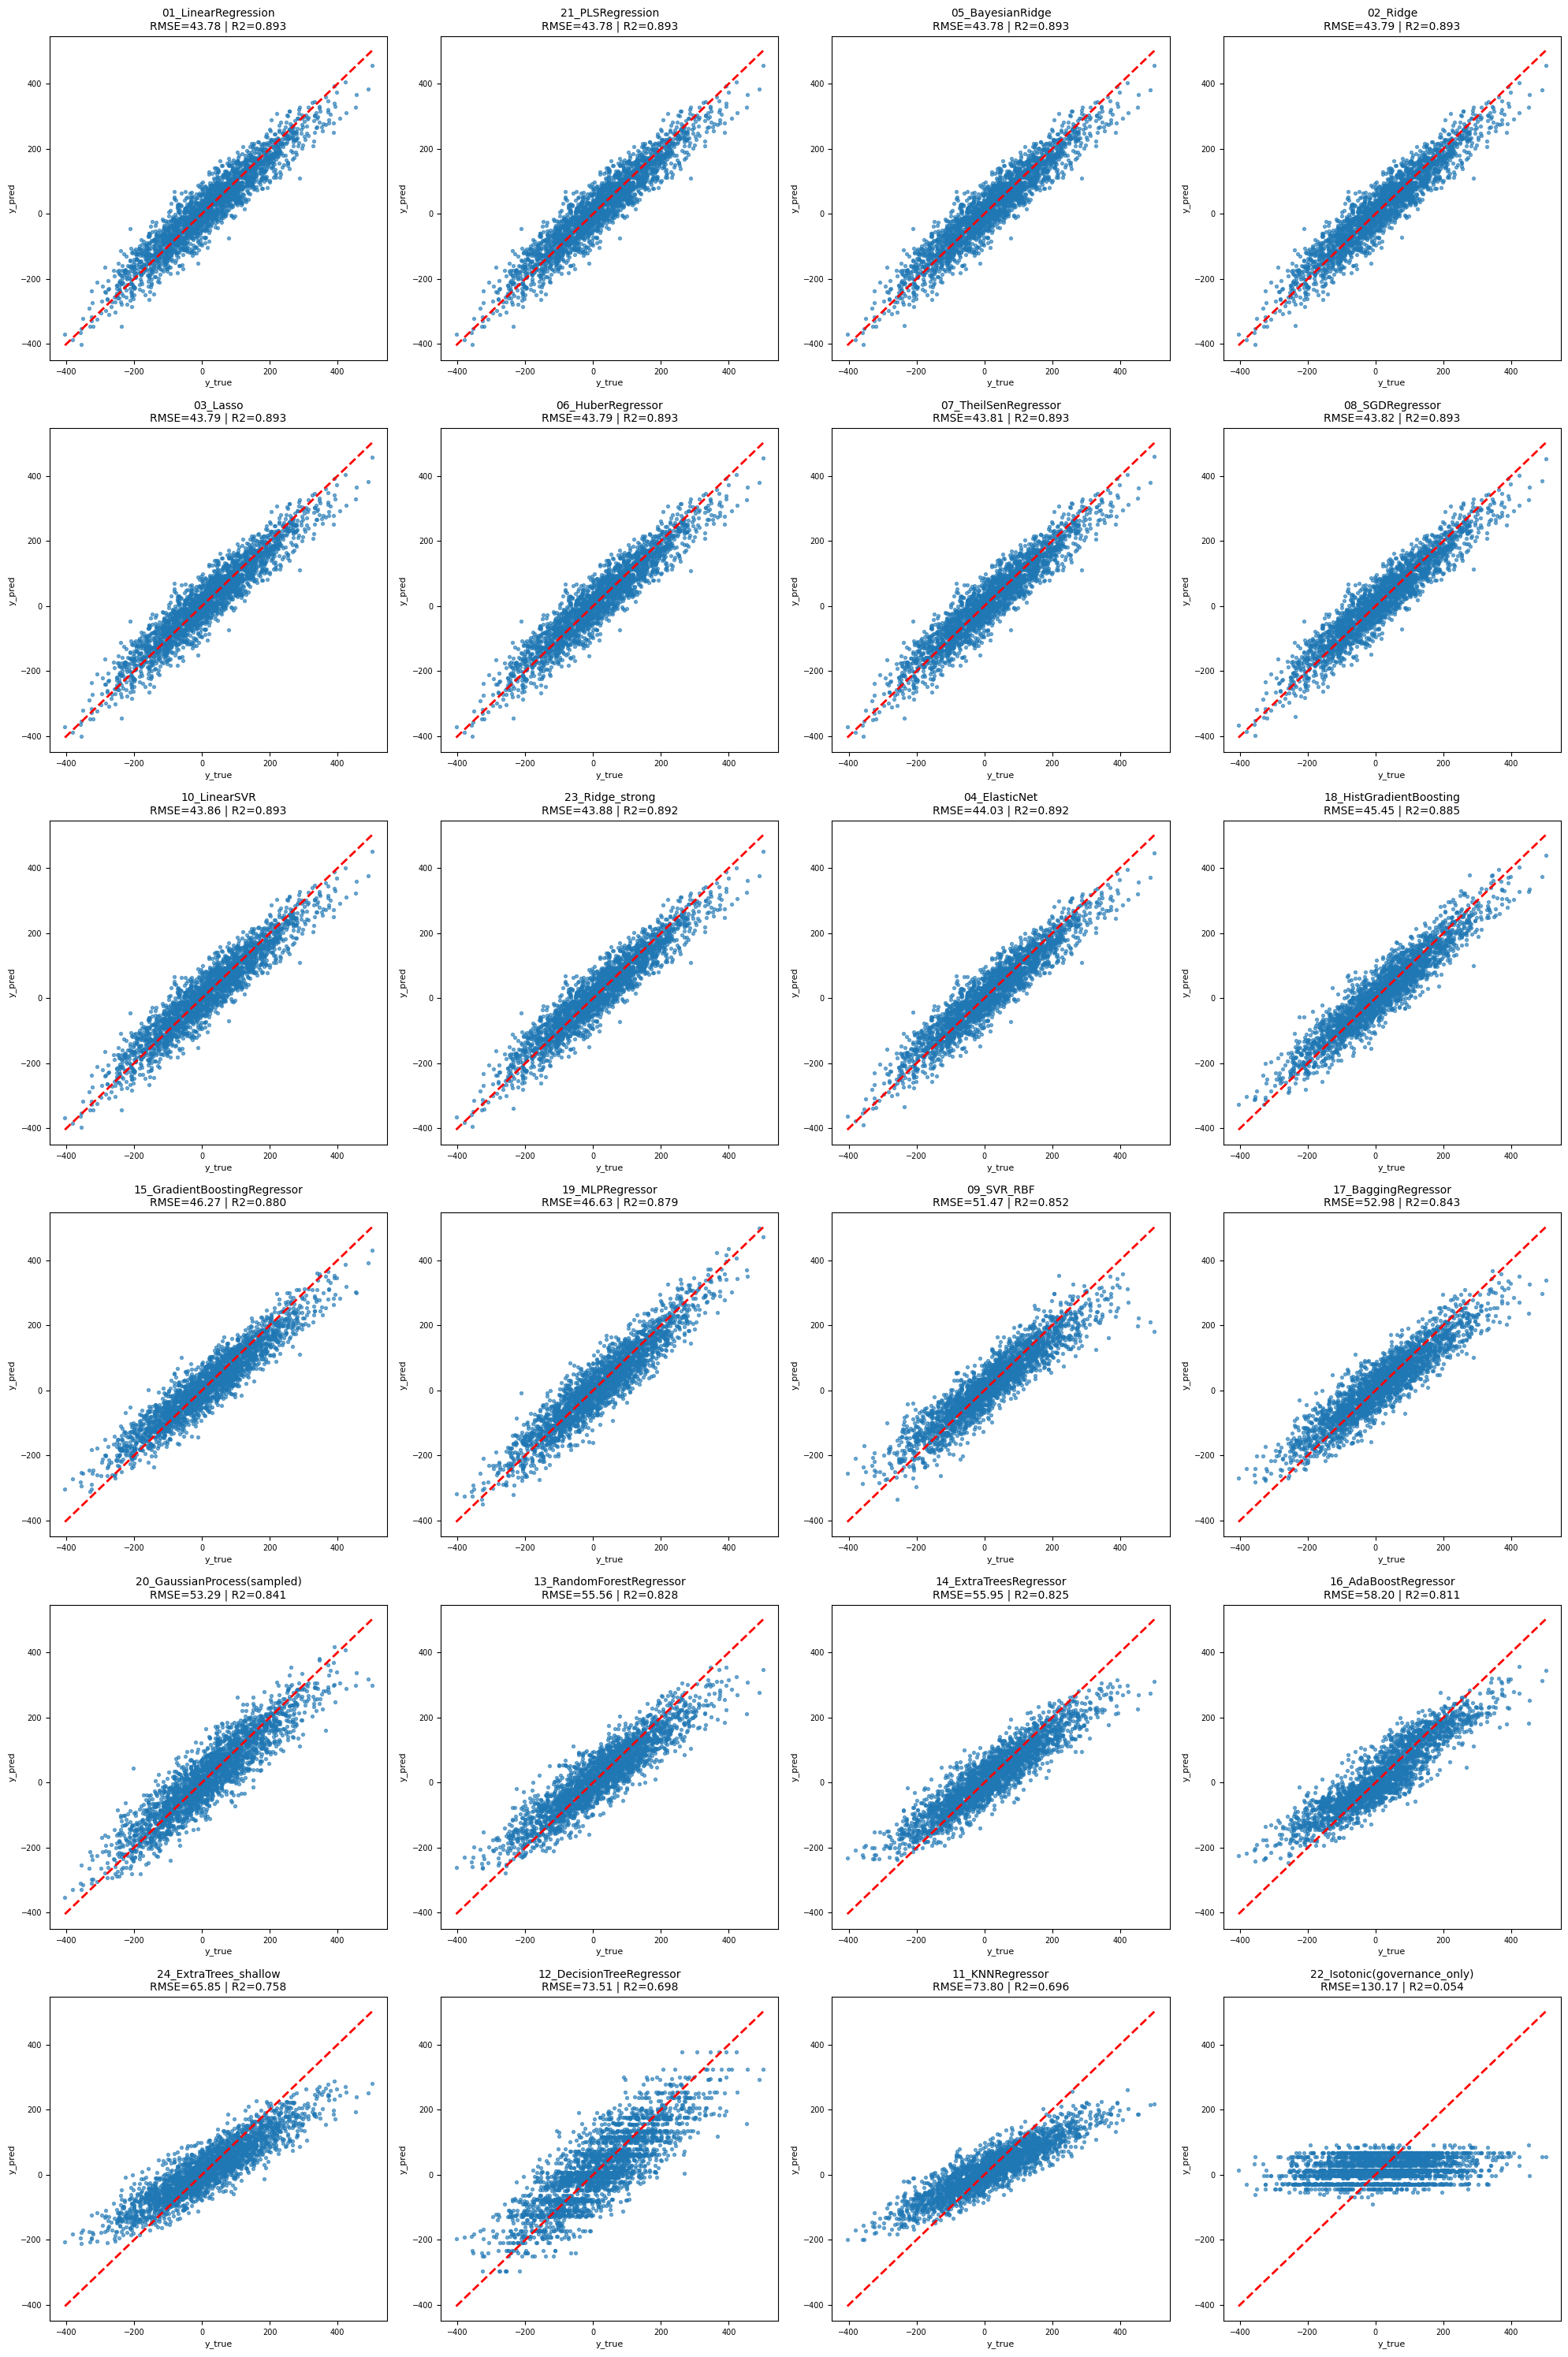

In [22]:
all_models = rank_final["model"].tolist()

# Adjust figure size for 24 plots (e.g., 4 rows, 6 columns)
fig, axes = plt.subplots(6, 4, figsize=(20, 30)) # 6 rows x 4 columns
axes = axes.ravel()

y_true = y_test.values

for i, name in enumerate(all_models):
    ax = axes[i]
    y_pred = preds_test[name]
    ax.scatter(y_true, y_pred, s=8, alpha=0.6)

    # Add perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--r', linewidth=2, label='Perfect prediction')

    # Use a smaller font size for title to fit 24 plots
    ax.set_title(f"{name}\nRMSE={rank_final.loc[rank_final['model']==name,'test_rmse'].values[0]:.2f} | R2={rank_final.loc[rank_final['model']==name,'test_r2'].values[0]:.3f}", fontsize=10)
    ax.set_xlabel("y_true", fontsize=8)
    ax.set_ylabel("y_pred", fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=7)
    # ax.legend(fontsize=7) # Optionally show legend, might clutter small plots

plt.tight_layout()
plt.show()

---
## ✅ Cierre

En este notebook:
- Generaste un dataset de **10,000** economías simuladas 🌍  
- Entrenaste y comparaste **24 modelos de regresión** 🤖  
- Calculaste métricas en Train/Val/Test 📏  
- Usaste gaps Train–Val para detectar over/underfitting 🔍  
- Construiste un ranking global (1–24) multi-métrica 🏆  

✅ Si quieres, puedo agregar también: **intervalos de confianza**, **bootstrap de RMSE**, o **validación cruzada** para mayor robustez.